<a href="https://colab.research.google.com/github/ayushi777lodhi-stack/Vision-MultiModal-Learning/blob/main/nanoVLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import math, random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import numpy as np

In [2]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [3]:
IMG_SIZE=32
EMB_DIM=64
ATT_HEADS=4
BATCH_SIZE=12
EPOCHS=50
LR=3e-4
TEMPERATURE=0.07

In [4]:
colors=['red','green','blue','yellow','purple','orange','pink','brown','gray']
shapes=['square','circle','triangle']
positions=['left','center','right','top','bottom','top-left','top-right','bottom-left','bottom-right']

In [6]:
def draw_sample(color, shape,position,img_size=IMG_SIZE):
  img=Image.new('RGB',(img_size,img_size),'white')
  draw=ImageDraw.Draw(img)

  margin=6
  h=w=img_size-2*margin
  if 'left' in position:
    x0=margin
    x1=margin+w//2
  elif 'top-left' in position:
    x0=margin
    x1=margin+w//2
  elif 'bottom-left' in position:
    x0=margin
    x1=margin+w//2
  elif 'right' in position:
    x0=margin+w//2
    x1=img_size-margin
  elif 'top-right' in position:
    x0=margin+w//2
    x1=img_size-margin
  elif 'bottom-right' in position:
    x0=margin+w//2
    x1=img_size-margin
  else:
    x0=margin+w//4
    x1=margin+3*w//4

  if 'top' in position:
    y0=margin
    y1=margin+h//2
  elif 'top-left' in position:
    y0=margin
    y1=margin+h//2
  elif 'top-right' in position:
    y0=margin
    y1=margin+h//2
  elif 'bottom' in position:
    y0=margin+h//2
    y1=img_size-margin
  elif 'bottom-left' in position:
    y0=margin+h//2
    y1=img_size-margin
  elif 'bottom-right' in position:
    y0=margin+h//2
    y1=img_size-margin
  else:
    y0=margin+h//4
    y1=margin+3*h//4

  if shape=='square':
    draw.rectangle([x0,y0,x1,y1],fill=color,outline='black')
  elif shape=='circle':
    draw.ellipse([x0,y0,x1,y1],fill=color,outline='black')
  else:
    draw.polygon([((x1+x0)//2,y0),(x0,y1),(x1,y1)],fill=color,outline='black')


  return img

In [24]:
class ShapeDataset(Dataset):
  def __init__(self):
    self.images=[]
    self.captions=[]

    for c in colors:
      for s in shapes:
        for p in positions:
          img=draw_sample(c,s,p)
          cap=f"{c} {s} {p}"

          self.images.append(torch.from_numpy(np.asarray(img).copy()).permute(2,0,1).float()/255.0)
          self.captions.append(cap)

    self.vocab,self.word2idx=self.build_vocab(self.captions)

  def build_vocab(self,texts):
      words=sorted({w for t in texts for w in t.split()})
      vocab= ['[CLS]'] +words
      w2i={w:i for i,w in enumerate(vocab)}
      return vocab,w2i

  def encode_text(self,text):
      toks=[self.word2idx['[CLS]']]+[self.word2idx[w] for w in text.split()]
      return torch.tensor(toks,dtype=torch.long)

  def __getitem__(self,idx):
      return self.images[idx],self.encode_text(self.captions[idx]),self.captions[idx]

  def __len__(self):
    return len(self.images)


In [25]:
full_ds=ShapeDataset()
VOCAB_SIZE=len(full_ds.vocab)
print(VOCAB_SIZE)
print(full_ds.vocab)

22
['[CLS]', 'blue', 'bottom', 'bottom-left', 'bottom-right', 'brown', 'center', 'circle', 'gray', 'green', 'left', 'orange', 'pink', 'purple', 'red', 'right', 'square', 'top', 'top-left', 'top-right', 'triangle', 'yellow']


In [9]:
train_size=int(0.8*len(full_ds))
val_size=len(full_ds)-train_size
train_ds,val_ds=torch.utils.data.random_split(full_ds,[train_size,val_size])

In [10]:
train_loader=DataLoader(train_ds,batch_size=BATCH_SIZE,shuffle=True,drop_last=True)
val_loader=DataLoader(val_ds,batch_size=BATCH_SIZE,shuffle=False,drop_last=True)

In [11]:
class ImagesEncode(nn.Module):
  def __init__(self,emb_dim=EMB_DIM):
    super().__init__()
    self.convs=nn.Sequential(
        nn.Conv2d(3,32,3,2,1),
        nn.ReLU(),
        nn.Conv2d(32,64,3,2,1),
        nn.ReLU(),
        nn.Conv2d(64,128,3,2,1),
        nn.ReLU(),
        nn.Conv2d(128,256,3,2,1),
        nn.ReLU()
    )
    self.projection=nn.Linear(256,emb_dim)
    self.layernorm1=nn.LayerNorm(emb_dim)


  def forward(self,x):
     x=self.convs(x)
     x=x.mean(dim=[2,3])
     x=self.projection(x)
     x=F.normalize(self.layernorm1(x),dim=-1)
     return x

In [12]:
class TextEncoder(nn.Module):
  def __init__(self, embed_dim=EMB_DIM, num_heads=ATT_HEADS,vocab_size=VOCAB_SIZE, context_window=4):
    super().__init__()
    self.token_embed=nn.Embedding(vocab_size,embed_dim)
    self.pos_embed=nn.Embedding(context_window,embed_dim)
    self.mha=nn.MultiheadAttention(embed_dim=embed_dim,num_heads=num_heads,batch_first=True)
    self.projection=nn.Linear(embed_dim,embed_dim)
    self.norm=nn.LayerNorm(embed_dim)

  def forward(self,toks):
    N,L=toks.shape
    position_emb_ids=torch.arange(L,device=toks.device).unsqueeze(0).expand(N,L)
    position_embedding_vectors=self.pos_embed(position_emb_ids)
    token_embedding_ids=toks
    token_embedding_vectors=self.token_embed(token_embedding_ids)
    final_embedding=token_embedding_vectors+position_embedding_vectors
    context_vectors,_=self.mha(final_embedding,final_embedding,final_embedding)
    final_token=context_vectors[:,0]
    projection = self.projection(final_token)
    projection = self.norm(projection)
    output = F.normalize(projection, dim=-1)
    return output


In [13]:
def clip_loss(img_emb,txt_emb,temperature=TEMPERATURE):
  logits=img_emb@txt_emb.T/temperature
  targets=torch.arange(img_emb.size(0),device=img_emb.device)
  loss_i=F.cross_entropy(logits,targets)
  loss_t=F.cross_entropy(logits.T,targets)
  return((loss_i+loss_t)/2.0)

In [14]:
img_enc=ImagesEncode().to(device)
txt_enc=TextEncoder().to(device)
params=list(img_enc.parameters())+list(txt_enc.parameters())
optimizer=torch.optim.Adam(params,lr=LR)


In [16]:
def show_image(t,title=None):
  img=(t.permute(1,2,0).numpy()*255).astype(np.uint(8))
  plt.figure(figsize=(3,3))
  plt.axis('off')
  if title:
    plt.title(title,fontsize=8)
  plt.imshow(img)
  plt.show()

image and caption:'orange triangle bottom-left


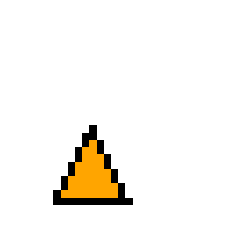

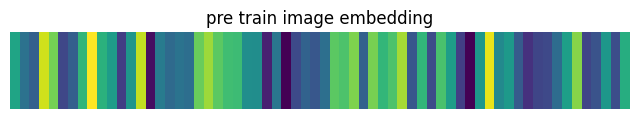

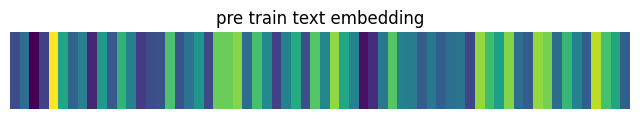

In [17]:
img_enc.eval()
txt_enc.eval()

with torch.no_grad():
  random_idx=random.randrange(len(full_ds))
  sample_img,sample_toks,sample_cap=full_ds[random_idx]
  sample_img=sample_img.unsqueeze(0).to(device)
  sample_toks=sample_toks.unsqueeze(0).to(device)
  pre_train_img_emb=img_enc(sample_img).squeeze(0).cpu().numpy()
  pre_train_txt_emb=txt_enc(sample_toks).squeeze(0).cpu().numpy()

  print(f"image and caption:'{sample_cap}")
  show_image(sample_img.squeeze(0).cpu())

  def plot_embedding(embedding,title):
    plt.figure(figsize=(8,1))
    plt.imshow(embedding.reshape(1,-1),aspect='auto',cmap='viridis')
    plt.title(title)
    plt.axis('off')
    plt.show()

  plot_embedding(pre_train_img_emb,"pre train image embedding")
  plot_embedding(pre_train_txt_emb,"pre train text embedding")

In [18]:
best_val=float('inf')
for epoch in range(1, EPOCHS+1):
  img_enc.train()
  txt_enc.train()
  total=0.0

  for imgs,toks,_ in train_loader:
    imgs=imgs.to(device)
    toks=toks.to(device)
    optimizer.zero_grad()
    ie=img_enc(imgs)
    te=txt_enc(toks)
    loss=clip_loss(ie,te)
    loss.backward()
    optimizer.step()
    total+=loss.item()*imgs.size(0)
  train_loss=total/(len(train_loader)*BATCH_SIZE)

  img_enc.eval()
  txt_enc.eval()

  with torch.no_grad():
    vtotal,n=0.0,0
    for imgs,toks,_ in val_loader:
      imgs=imgs.to(device)
      toks=toks.to(device)
      vtotal+=clip_loss(img_enc(imgs),txt_enc(toks)).item()*imgs.size(0)
      n+=imgs.size(0)
    val_loss=vtotal/n

  print(f"epoch:{epoch:02d} train:{train_loss:.4f} val:{val_loss:.4f}")
  best_val=min(best_val,val_loss)

epoch:01 train:2.5313 val:2.4729
epoch:02 train:2.3994 val:2.2614
epoch:03 train:1.4934 val:0.8304
epoch:04 train:0.7928 val:0.4330
epoch:05 train:0.5855 val:0.3490
epoch:06 train:0.5292 val:0.4395
epoch:07 train:0.4423 val:0.2483
epoch:08 train:0.3906 val:0.3807
epoch:09 train:0.3668 val:0.1871
epoch:10 train:0.3384 val:0.2033
epoch:11 train:0.2722 val:0.1972
epoch:12 train:0.2744 val:0.1351
epoch:13 train:0.2661 val:0.1261
epoch:14 train:0.2872 val:0.1211
epoch:15 train:0.2316 val:0.1208
epoch:16 train:0.2112 val:0.1207
epoch:17 train:0.1798 val:0.1486
epoch:18 train:0.1978 val:0.1560
epoch:19 train:0.2294 val:0.3247
epoch:20 train:0.2182 val:0.0933
epoch:21 train:0.1524 val:0.0959
epoch:22 train:0.2557 val:0.1925
epoch:23 train:0.1587 val:0.1141
epoch:24 train:0.1960 val:0.0898
epoch:25 train:0.1479 val:0.0807
epoch:26 train:0.1298 val:0.0662
epoch:27 train:0.1202 val:0.0545
epoch:28 train:0.0879 val:0.0450
epoch:29 train:0.0746 val:0.0365
epoch:30 train:0.0976 val:0.0373
epoch:31 t

image and caption:'pink triangle right


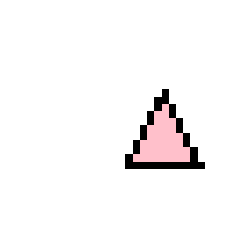

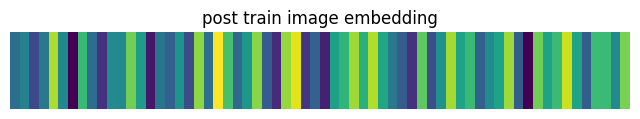

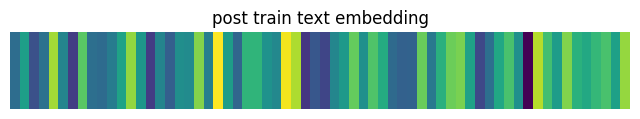

In [19]:
img_enc.eval()
txt_enc.eval()

with torch.no_grad():
  random_idx=random.randrange(len(full_ds))
  sample_img,sample_toks,sample_cap=full_ds[random_idx]
  sample_img=sample_img.unsqueeze(0).to(device)
  sample_toks=sample_toks.unsqueeze(0).to(device)
  post_train_img_emb=img_enc(sample_img).squeeze(0).cpu().numpy()
  post_train_txt_emb=txt_enc(sample_toks).squeeze(0).cpu().numpy()

  print(f"image and caption:'{sample_cap}")
  show_image(sample_img.squeeze(0).cpu())

  def plot_embedding(embedding,title):
    plt.figure(figsize=(8,1))
    plt.imshow(embedding.reshape(1,-1),aspect='auto',cmap='viridis')
    plt.title(title)
    plt.axis('off')
    plt.show()

  plot_embedding(post_train_img_emb,"post train image embedding")
  plot_embedding(post_train_txt_emb,"post train text embedding")

In [20]:
print("dot product between image and text embedding")
print(f"before training: {np.dot(pre_train_img_emb,pre_train_txt_emb):.4f}")
print(f"after training:{np.dot(post_train_img_emb,post_train_txt_emb):.4f}")

dot product between image and text embedding
before training: 0.0419
after training:0.8888


In [21]:
img_enc.eval()
txt_enc.eval()

with torch.no_grad():
  val_imgs,val_toks,val_caps=[],[],[]
  for imgs,toks,caps in val_loader:
    val_imgs.append(imgs)
    val_toks.append(toks)
    val_caps+=list(caps)
  val_imgs=torch.cat(val_imgs).to(device)
  val_toks=torch.cat(val_toks).to(device)
  img_emb=img_enc(val_imgs)
  txt_emb=txt_enc(val_toks)



In [22]:
def topk_text_for_images(k=3,idxs=None):
  if idxs is None:
    idxs=np.random.choice(len(val_caps),size=1,replace=False)
    sims=(img_emb@txt_emb.t()).softmax(dim=1)
    for i in idxs:
      best=sims[i].topk(k).indices.tolist()
      print(f"image{i} best caption:")
      for j in best:
        print(" -",val_caps[j])
      show_image(val_imgs[i].cpu())

def topk_images_for_text(k=3,idxs=None):
  if idxs is None:
    idxs=np.random.choice(len(val_caps),size=1,replace=False)
    sims=(txt_emb@img_emb.t()).softmax(dim=1)
    for i in idxs:
      best=sims[i].topk(k).indices.tolist()
      print(f"text'{val_caps[i]}' best image:")
      for j in best:
         show_image(val_imgs[j].cpu(),title=f"match {val_caps[j]}")



image17 best caption:
 - purple triangle right


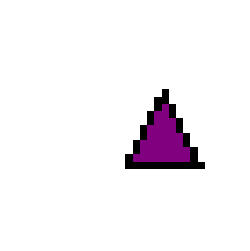

text'yellow circle top-left' best image:


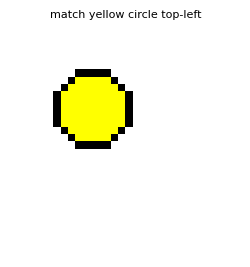

In [23]:
topk_text_for_images(k=1)
topk_images_for_text(k=1)